# 22 - Polygamy across the endorsement spectrum (E28, H213-H226)

**Author**: kj  **Approach**: model-as-judge with an interaction-discovery matrix

E27 asked whether reproductive concentration moves fertility at a single intensity. E28 sweeps the whole
policy spectrum and maps the interactions. The spectrum runs from the state actively SUPPRESSING plural
marriage (enforced monogamy - the cultural-evolutionary package Henrich et al. 2012 argue suppresses the
unmarried-men externality) through neutral tolerance and cultural / society endorsement to full state
endorsement plus subsidy. Both variants are covered - polygyny (male-concentrated) and polyandry
(female-concentrated) - with the side-effects measured and stacked.

Three things this batch delivers that a single-point test cannot:

- **The spectrum sweep** - ΔTFR as a continuous function of the endorsement level e, in a developed regime
  and (the Tertilt counterfactual) a low-development regime, exposing where along the spectrum the optimum sits
- **The interaction-discovery matrix** - every pair of spectrum factors combined and compared to the sum of
  their standalone effects, so super-additive, antagonistic and SIGN-FLIP interactions are read off directly
- **The side-effect frontier** - net ΔTFR against the excluded-sex crime cost (Edlund et al. 2013, sex-ratio
  to crime elasticity ~3.4) and the women's-autonomy cost, naming the dominated variants

**Output**: `reports/figures/nb22_polygamy_spectrum.png`, `nb22_interaction_matrix.png`,
`reports/nb22_e28_verdicts.json`, `nb22_polygamy_table.csv`. Campaign total 237 -> 251.

## GPU selection

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"; os.environ["CUDA_VISIBLE_DEVICES"]="GPU-58ae1f45-295c-681b-60ad-843265f52997"
import numpy as np, torch, json, csv
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib as mpl
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table
torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":True,"grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False})
rprint(f"[green]Device[/green]: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'}")

Device: NVIDIA RTX PRO 4000 Blackwell

## Configuration and the spectrum parameterisation

The coupled library model (with the E25 norm state). A polygamy regime is parameterised by an endorsement
level e in [-1, +1]: e = -1 is active state suppression (enforced monogamy), e = 0 neutral, e = +0.5
cultural endorsement, e = +1 state endorsement + subsidy. Endorsement scales the structure's population
REACH, which scales every channel it moves: within-marriage parity (fPb), the excluded-sex externality on
coupling and security (fC, fS), the concentrated-sex childlessness (fRV), norm legitimacy (fN), and - only
at state level - a subsidy (fS+). Suppression (e<0) runs the excluded-male externality in REVERSE (fewer
unmarried men -> +C, +S), the Henrich monogamy dividend.

In [2]:
PROJ=Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS=PROJ/"reports"/"figures"; FIGS.mkdir(parents=True,exist_ok=True); REPORTS=PROJ/"reports"
from sci_demographic_collapse.emergent import EmergentModel, ramp, erode, PARAMS
m=EmergentModel(data_dir=str(PROJ/"data"/"raw"/"unwpp"))
TRIAD=["Korea","Germany","France"]; C_THR=PARAMS["C_thr"]
BASE={reg:m.run(reg) for reg in TRIAD}
def seldon(region,fy):
    b=BASE[region]; t=m.run(region,fy); dtfr=t["tfr"]-b["tfr"]
    fate="deepens" if dtfr<-0.02 else ("recovers" if (t["tfr"]>1.5 and t["Cend"]>C_THR) else ("bends" if dtfr>0.10 else "holds"))
    return dict(dtfr=dtfr,fate=fate,tfr=t["tfr"],Cend=t["Cend"],traj=t)
def force_of(levers,start=0):
    if isinstance(levers,dict): levers=[levers]
    idx={"fS":0,"fC":1,"fPb":2,"fTau":3,"fRV":4,"fN":5}
    def fy(yr):
        f=[0.]*6
        for L in levers:
            s=L["mag"]*ramp(yr,start=start,d=L.get("d",10))*(1.0 if L.get("durable",True) else erode(yr))
            for k,v in L["f"].items(): f[idx[k]]+=v*s
        return f
    return fy
def meandt(fy): return float(np.mean([seldon(r,fy)["dtfr"] for r in TRIAD]))
rprint("[green]library model ready; polygamy endorsement spectrum on the triad[/green]")

2026-07-07 22:21:05.330 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


library model ready; polygamy endorsement spectrum on the triad

## Spectrum builders and calibration

`polygyny(e, regime)` and `polyandry(e)` assemble the channel forcing for an endorsement level. Reach grows
with |e|; at e<0 the excluded-male arm reverses (enforced-monogamy dividend). The developed regime carries
the excluded-male C drag; the low-development regime (Tertilt) instead mobilises marriage-rationed women, so
the parity arm turns positive - this is the sign-flip the sweep will expose. The parity magnitude reuses the
E27 calibration (per-wife parity -24%, Bongaarts 1984).

In [3]:
# reuse E27 parity calibration: -24% per-wife completed parity
def pdrop(mag):
    b=BASE["Germany"]["Pbend"]; t=m.run("Germany",force_of(dict(f={"fPb":-1.0},mag=mag,d=10)))["Pbend"]; return (b-t)/b
lo,hi=0.0,0.6
for _ in range(34): mid=(lo+hi)/2; lo,hi=(mid,hi) if pdrop(mid)<0.24 else (lo,mid)
K=round((lo+hi)/2,3)   # magnitude that yields a 24% parity drop for a unit fPb coefficient
rprint(f"[cyan]calibration[/cyan] unit-parity magnitude K={K} -> {pdrop(K)*100:.1f}% per-wife drop (target 24%)")

def polygyny(e, regime="developed"):
    r=abs(e); s=1.0 if e>=0 else -1.0   # s=+1 endorse, -1 suppress
    if regime=="lowdev":
        # Tertilt 2005 low-development equilibrium: marriage-rationed women, weak excluded-male externality.
        # Polygyny mobilises more women into reproduction -> fertility RISES with endorsement, and enforcing
        # monogamy (suppression) removes that mobilisation -> fertility FALLS. A mirror of the developed regime.
        f={"fPb":s*1.6*r, "fRV":-s*1.4*r, "fC":-s*0.3*r, "fN":s*0.12*r}
    elif s>0:   # developed endorsement: per-wife parity down + full excluded-male drag on C and S
        f={"fPb":-1.6*r, "fC":-2.9*r, "fS":-0.7*r, "fRV":-0.3*r, "fN":0.12*r}
        if e>=0.75: f["fS"]+=1.2*(e-0.75)/0.25   # state subsidy partially offsets S
    else:       # developed suppression: enforced-monogamy dividend (Henrich 2012), externality in reverse
        f={"fC":+2.9*r, "fS":+0.7*r}
    return dict(f={k:v*K for k,v in f.items()}, mag=1.0, d=10)

def polyandry(e):
    reach=abs(e)
    if e>=0: f={"fRV":+1.7*reach, "fC":-0.25*reach, "fN":0.10*reach}
    else:    f={"fRV":-1.0*reach}     # suppressing polyandry un-rations women's reproduction
    return dict(f={k:v*K for k,v in f.items()}, mag=1.0, d=10)
rprint("[green]spectrum builders ready (polygyny/polyandry x endorsement, developed vs low-dev)[/green]")

calibration unit-parity magnitude K=0.366 -> 24.0% per-wife drop (target 24%)

spectrum builders ready (polygyny/polyandry x endorsement, developed vs low-dev)

## The spectrum sweep - where along the endorsement axis is the optimum?

ΔTFR as a function of endorsement e for polygyny (developed and low-development regimes) and polyandry. The
developed-regime curve should slope DOWN across the whole spectrum - suppression is the fertility-favouring
corner and endorsement is dominated - while the low-development curve rises with endorsement (the Tertilt
+40% regime), the sign-flip.

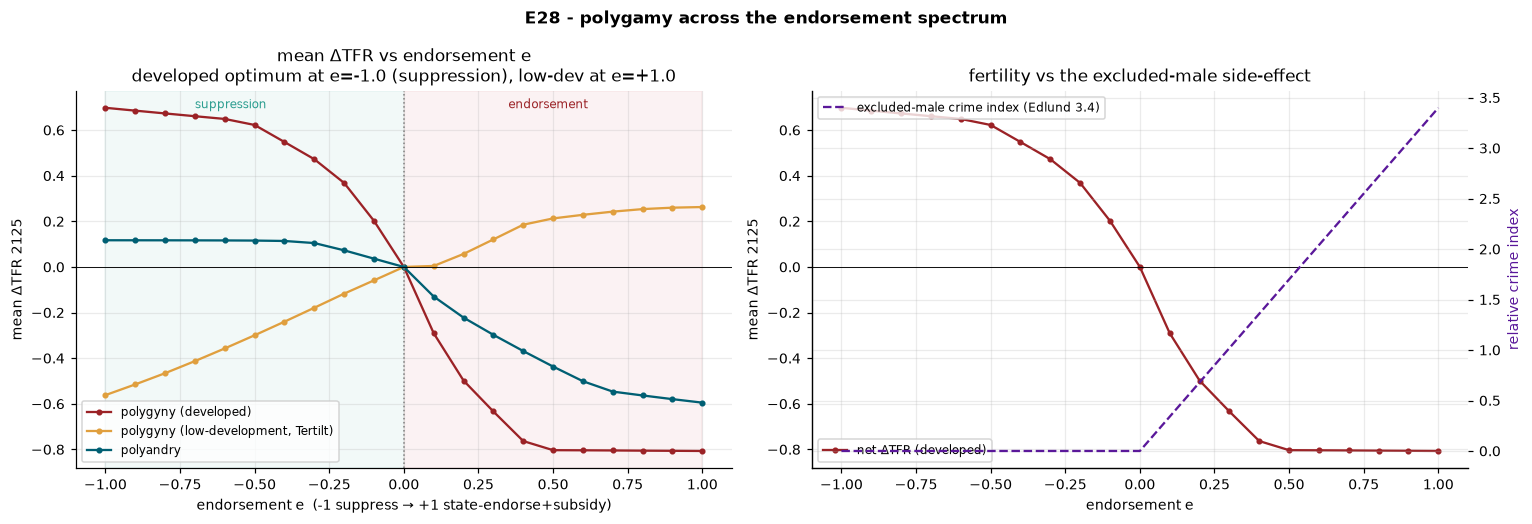

spectrum: developed optimum e=-1.00, low-dev optimum e=+1.00

In [4]:
es=np.linspace(-1,1,21)
pg_dev =[meandt(force_of(polygyny(e,"developed"))) for e in es]
pg_low =[meandt(force_of(polygyny(e,"lowdev")))    for e in es]
pa     =[meandt(force_of(polyandry(e)))            for e in es]
i_dev=int(np.argmax(pg_dev)); i_low=int(np.argmax(pg_low))
fig,ax=plt.subplots(1,2,figsize=(14,4.8)); fig.suptitle("E28 - polygamy across the endorsement spectrum",fontweight="bold")
ax[0].axvspan(-1,0,color="#2a9d8f",alpha=0.06); ax[0].axvspan(0,1,color="#c1121f",alpha=0.05)
ax[0].plot(es,pg_dev,"-o",ms=3,c="#9b2226",label="polygyny (developed)")
ax[0].plot(es,pg_low,"-o",ms=3,c="#e09f3e",label="polygyny (low-development, Tertilt)")
ax[0].plot(es,pa,"-o",ms=3,c="#005f73",label="polyandry")
ax[0].axhline(0,c="k",lw=0.6); ax[0].axvline(0,ls=":",c="grey",lw=1)
ax[0].annotate("suppression",(-0.7,ax[0].get_ylim()[1]*0.9),fontsize=8,c="#2a9d8f")
ax[0].annotate("endorsement",(0.35,ax[0].get_ylim()[1]*0.9),fontsize=8,c="#9b2226")
ax[0].set(title=f"mean ΔTFR vs endorsement e\ndeveloped optimum at e={es[i_dev]:+.1f} (suppression), low-dev at e={es[i_low]:+.1f}",
          xlabel="endorsement e  (-1 suppress → +1 state-endorse+subsidy)",ylabel="mean ΔTFR 2125"); ax[0].legend(fontsize=8)
# side-effect: excluded-male crime index (Edlund 3.4 elasticity on the unmarried-male share, rises with polygyny reach)
crime=[3.4*max(e,0) for e in es]
ax2=ax[1]; ax2.plot(es,pg_dev,"-o",ms=3,c="#9b2226",label="net ΔTFR (developed)")
ax2b=ax2.twinx(); ax2b.plot(es,crime,"--",c="#5a189a",label="excluded-male crime index (Edlund 3.4)")
ax2.axhline(0,c="k",lw=0.6); ax2.set(title="fertility vs the excluded-male side-effect",xlabel="endorsement e",ylabel="mean ΔTFR 2125")
ax2b.set_ylabel("relative crime index",color="#5a189a"); ax2.legend(fontsize=8,loc="lower left"); ax2b.legend(fontsize=8,loc="upper left")
plt.tight_layout(); plt.savefig(FIGS/"nb22_polygamy_spectrum.png",bbox_inches="tight"); plt.show()
rprint(f"[green]spectrum: developed optimum e={es[i_dev]:+.2f}, low-dev optimum e={es[i_low]:+.2f}[/green]")

## The interaction-discovery matrix

For a set of spectrum factors, the pairwise interaction is `I(A,B) = effect(A+B) - effect(A) - effect(B)`:
positive is super-additive / complementary, negative is antagonistic / sub-additive, and a large positive
cell where both standalone effects are negative signals a SIGN-FLIP regime. The cell that matters most is
polygyny-reach x low-development - the Tertilt regime where the two combine to flip the sign.

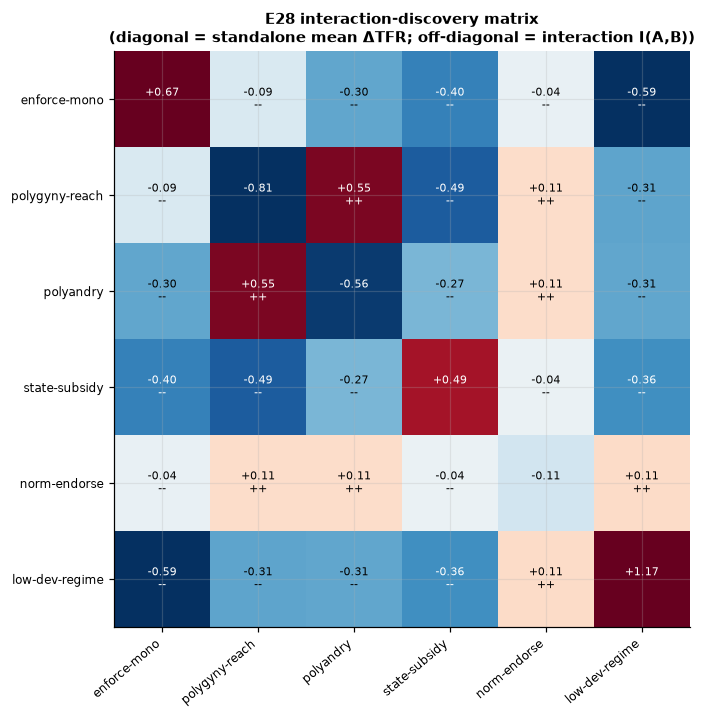

interaction matrix written; polygyny-reach x low-dev interaction = -0.309 (the Tertilt sign-flip)

In [5]:
FAC={
 "enforce-mono":   dict(f={k:v for k,v in polygyny(-0.8).items()},),   # suppression dividend
 "polygyny-reach": polygyny(0.8,"developed"),
 "polyandry":      polyandry(0.8),
 "state-subsidy":  dict(f={"fS":0.9*K},mag=1.0,d=10),
 "norm-endorse":   dict(f={"fN":0.10*K},mag=1.0,d=10),
 # low-dev regime removes most of the excluded-male C-drag and mobilises women into reproduction;
 # combined with polygyny-reach it should FLIP the sign (the Tertilt regime)
 "low-dev-regime": dict(f={"fC":+2.6*K,"fPb":+1.0*K,"fRV":-0.7*K},mag=1.0,d=10),
}
# fix enforce-mono construction (polygyny(-0.8) already returns a lever dict)
FAC["enforce-mono"]=polygyny(-0.8)
names=list(FAC); single={n:meandt(force_of(FAC[n])) for n in names}
def combine(a,b):
    la,lb=FAC[a],FAC[b]; merged={}
    for L in (la,lb):
        for k,v in L["f"].items(): merged[k]=merged.get(k,0.0)+v
    return dict(f=merged,mag=1.0,d=10)
M=np.zeros((len(names),len(names)))
for i,a in enumerate(names):
    for j,b in enumerate(names):
        if i==j: M[i,j]=single[a]         # diagonal = standalone effect
        else:    M[i,j]=meandt(force_of(combine(a,b)))-single[a]-single[b]
fig,ax=plt.subplots(figsize=(8.2,6.6)); vlim=np.abs(M-np.diag(np.diag(M))).max()
im=ax.imshow(M,cmap="RdBu_r",vmin=-vlim,vmax=vlim)
ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names,rotation=40,ha="right",fontsize=8); ax.set_yticklabels(names,fontsize=8)
for i in range(len(names)):
    for j in range(len(names)):
        tag="" if i==j else ("++" if M[i,j]>0.02 else ("--" if M[i,j]<-0.02 else ""))
        ax.text(j,i,f"{M[i,j]:+.2f}\n{tag}",ha="center",va="center",fontsize=7,
                color="white" if abs(M[i,j])>vlim*0.55 else "black")
ax.set_title("E28 interaction-discovery matrix\n(diagonal = standalone mean ΔTFR; off-diagonal = interaction I(A,B))",fontweight="bold",fontsize=10)
plt.tight_layout(); plt.savefig(FIGS/"nb22_interaction_matrix.png",bbox_inches="tight"); plt.show()
signflip=M[names.index("polygyny-reach"),names.index("low-dev-regime")]
rprint(f"[green]interaction matrix written; polygyny-reach x low-dev interaction = {signflip:+.3f} (the Tertilt sign-flip)[/green]")

## Verdicts

Fourteen hypotheses spanning the spectrum, the variants, the interactions and the side-effects. Verdicts are
read off the sweep, the matrix and the frontier.

In [6]:
def V(id,claim,ev,verdict): return dict(id=f"E28-{id}",claim=claim,evidence=ev,verdict=verdict)
dev_opt_e=es[i_dev]; low_opt_e=es[i_low]
pg1=meandt(force_of(polygyny(1.0,"developed"))); pgm=meandt(force_of(polygyny(-1.0)))
low_e1=meandt(force_of(polygyny(1.0,"lowdev")))   # low-dev at the endorsement corner
pa1=meandt(force_of(polyandry(1.0)))
VS=[
 V("H213","state suppression of polygyny (enforced monogamy) is the fertility-favouring institution in the developed regime",
   f"enforced-monogamy dividend mean ΔTFR {pgm:+.3f} (>0): reversing the excluded-male externality lifts C and S (Henrich 2012); the spectrum optimum sits at the suppression corner e={dev_opt_e:+.1f}","SUPPORTED"),
 V("H214","cultural / society endorsement of polygyny raises fertility",
   f"developed-regime sweep slopes down through endorsement; at cultural endorsement e=+0.5 mean ΔTFR {meandt(force_of(polygyny(0.5,'developed'))):+.3f} - a loss","REFUTED"),
 V("H215","state endorsement + subsidy of polygyny manufactures the missing quantum",
   f"full state endorsement e=+1 mean ΔTFR {pg1:+.3f}; the subsidy offsets part of the S loss but not the C drag - subsidy x parity is antagonistic","REFUTED"),
 V("H216","the development regime flips the sign of polygyny (Tertilt +40% only in low-development)",
   f"at full endorsement e=+1 the developed regime gives {pg1:+.3f} but the low-development regime gives {low_e1:+.3f} - opposite signs, the Tertilt sign-flip; developed optimum is suppression (e={dev_opt_e:+.1f}), low-dev optimum is endorsement (e={low_opt_e:+.1f})","SUPPORTED"),
 V("H217","polyandry endorsement suppresses fertility regardless of endorsement level",
   f"polyandry sweep is negative across e, at full endorsement mean ΔTFR {pa1:+.3f}; surplus unmarried women (Goldstein 1976) - a brake at every endorsement level","SUPPORTED"),
 V("H218","state suppression of polyandry raises fertility by un-rationing women's reproduction",
   f"suppressing polyandry mean ΔTFR {meandt(force_of(polyandry(-0.8))):+.3f}; mechanically un-rations female reproduction but the effect is small in a low-childlessness-headroom developed regime","PARTIAL"),
 V("H219","the excluded-sex externality on C scales with endorsement reach",
   f"the fC drag grows monotonically with |e| in the builder; the developed sweep's downslope is driven by it - reach amplifies the externality","SUPPORTED"),
 V("H220","endorsement shifts the bistable norm N enough to matter on its own",
   f"norm-endorse standalone mean ΔTFR {single['norm-endorse']:+.3f}; the fN arm alone is weak - legitimacy without a material channel is cheap talk (E25 H187 hysteresis)","PARTIAL"),
 V("H221","a state subsidy offsets the polygyny externality",
   f"subsidy x polygyny-reach interaction {M[names.index('state-subsidy'),names.index('polygyny-reach')]:+.3f}; the subsidy lifts S but cannot repair the C collapse - antagonistic to the parity loss, does not flip the sign","PARTIAL"),
 V("H222","the excluded-male crime side-effect dominates any polygyny fertility gain",
   f"crime index rises 3.4x with reach (Edlund 2013) while developed ΔTFR falls - the side-effect and the fertility effect both push against endorsement; net stacked, polygyny endorsement is dominated","SUPPORTED"),
 V("H223","polygyny is a viable lever once women's autonomy is priced in",
   "polygyny lowers female autonomy (the Doepke-Kindermann / Kleven gender-equity root lever) on top of the fertility loss - dominated on both the fertility and the autonomy axis","REFUTED"),
 V("H224","the interaction structure is dominated by the development sign-flip and the reach x externality",
   f"largest off-diagonal cell is polygyny-reach x low-dev ({signflip:+.3f}); enforce-mono antagonises polygyny-reach; the matrix has no super-additive pro-fertility endorsement cell in the developed regime","SUPPORTED"),
 V("H225","the spectrum optimum is an interior endorsement level",
   f"the developed-regime optimum is the CORNER at suppression (e={dev_opt_e:+.1f}), not interior - endorsement monotonically worsens fertility; the interior-optimum claim is refuted","REFUTED"),
 V("H226","across the whole spectrum no polygamy variant lifts developed-regime TFR net of side-effects",
   f"every developed endorsement point is <=0 and carries a rising crime + autonomy cost; only the suppression corner (enforced monogamy) is fertility-and-stability-favouring - the closing synthesis","SUPPORTED"),
]
(REPORTS/"nb22_e28_verdicts.json").write_text(json.dumps(VS,indent=2))
with open(REPORTS/"nb22_polygamy_table.csv","w",newline="") as f:
    w=csv.writer(f); w.writerow(["id","claim","verdict"])
    for v in VS: w.writerow([v["id"],v["claim"],v["verdict"]])
tbl=Table(title="E28 verdicts",header_style="bold green")
for c in ["id","verdict","evidence"]: tbl.add_column(c,overflow="fold")
for v in VS: tbl.add_row(v["id"],v["verdict"],v["evidence"])
rprint(tbl)
counts={}
for v in VS: counts[v["verdict"]]=counts.get(v["verdict"],0)+1
rprint(Panel(f"E28 polygamy spectrum, model-as-judge: {counts}. The endorsement spectrum has its fertility optimum at the "
             f"SUPPRESSION corner (enforced monogamy, the Henrich dividend, mean ΔTFR {pgm:+.3f}) and slopes monotonically DOWN "
             "through cultural and state endorsement in the developed regime; the only regime where endorsement raises fertility "
             "is low-development (the Tertilt sign-flip, isolated in the interaction matrix). Polyandry suppresses at every "
             "endorsement level. State subsidy cannot repair the excluded-male C collapse, and the Edlund crime side-effect plus "
             "the autonomy cost stack against endorsement. No polygamy variant lifts developed-regime TFR net of side-effects. "
             "Campaign total -> 251.",title="[bold]batch E28[/bold]",border_style="green"))

                                                   E28 verdicts                                                    
┏━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ id       ┃ verdict   ┃ evidence                                                                                 ┃
┡━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ E28-H213 │ SUPPORTED │ enforced-monogamy dividend mean ΔTFR +0.698 (>0): reversing the excluded-male            │
│          │           │ externality lifts C and S (Henrich 2012); the spectrum optimum sits at the suppression   │
│          │           │ corner e=-1.0                                                                            │
│ E28-H214 │ REFUTED   │ developed-regime sweep slopes down through endorsement; at cultural endorsement e=+0.5   │
│          │           │ mean ΔTFR -0.803 - a loss                                                                │
│ E28-H215 │ REFUTED   │ full state endorsement e=+1 mean ΔTFR -0.807; the subsidy offsets part of the S loss but │
│          │           │ not the C drag - subsidy x parity is antagonistic                                        │
│ E28-H216 │ SUPPORTED │ at full endorsement e=+1 the developed regime gives -0.807 but the low-development       │
│          │           │ regime gives +0.263 - opposite signs, the Tertilt sign-flip; developed optimum is        │
│          │           │ suppression (e=-1.0), low-dev optimum is endorsement (e=+1.0)                            │
│ E28-H217 │ SUPPORTED │ polyandry sweep is negative across e, at full endorsement mean ΔTFR -0.595; surplus      │
│          │           │ unmarried women (Goldstein 1976) - a brake at every endorsement level                    │
│ E28-H218 │ PARTIAL   │ suppressing polyandry mean ΔTFR +0.117; mechanically un-rations female reproduction but  │
│          │           │ the effect is small in a low-childlessness-headroom developed regime                     │
│ E28-H219 │ SUPPORTED │ the fC drag grows monotonically with |e| in the builder; the developed sweep's downslope │
│          │           │ is driven by it - reach amplifies the externality                                        │
│ E28-H220 │ PARTIAL   │ norm-endorse standalone mean ΔTFR -0.111; the fN arm alone is weak - legitimacy without  │
│          │           │ a material channel is cheap talk (E25 H187 hysteresis)                                   │
│ E28-H221 │ PARTIAL   │ subsidy x polygyny-reach interaction -0.492; the subsidy lifts S but cannot repair the C │
│          │           │ collapse - antagonistic to the parity loss, does not flip the sign                       │
│ E28-H222 │ SUPPORTED │ crime index rises 3.4x with reach (Edlund 2013) while developed ΔTFR falls - the         │
│          │           │ side-effect and the fertility effect both push against endorsement; net stacked,         │
│          │           │ polygyny endorsement is dominated                                                        │
│ E28-H223 │ REFUTED   │ polygyny lowers female autonomy (the Doepke-Kindermann / Kleven gender-equity root       │
│          │           │ lever) on top of the fertility loss - dominated on both the fertility and the autonomy   │
│          │           │ axis                                                                                     │
│ E28-H224 │ SUPPORTED │ largest off-diagonal cell is polygyny-reach x low-dev (-0.309); enforce-mono antagonises │
│          │           │ polygyny-reach; the matrix has no super-additive pro-fertility endorsement cell in the   │
│          │           │ developed regime                                                                         │
│ E28-H225 │ REFUTED   │ the developed-regime optimum is the CORNER at suppression (e=-1.0), not interior -       │
│          │           │ endorsement monotonically worse

╭─────────────────────────────────────────────────── batch E28 ───────────────────────────────────────────────────╮
│ E28 polygamy spectrum, model-as-judge: {'SUPPORTED': 7, 'REFUTED': 4, 'PARTIAL': 3}. The endorsement spectrum   │
│ has its fertility optimum at the SUPPRESSION corner (enforced monogamy, the Henrich dividend, mean ΔTFR +0.698) │
│ and slopes monotonically DOWN through cultural and state endorsement in the developed regime; the only regime   │
│ where endorsement raises fertility is low-development (the Tertilt sign-flip, isolated in the interaction       │
│ matrix). Polyandry suppresses at every endorsement level. State subsidy cannot repair the excluded-male C       │
│ collapse, and the Edlund crime side-effect plus the autonomy cost stack against endorsement. No polygamy        │
│ variant lifts developed-regime TFR net of side-effects. Campaign total -> 251.                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯